  Employee_ID  Age  Training_Hours  Green_Skill_Score Energy_Saving_Practice  \
0        E001   24              40                 78                   High   
1        E002   29              25                 65                 Medium   
2        E003   35              60                 90                   High   
3        E004   42              20                 55                    Low   
4        E005   31              45                 82                   High   

   Carbon_Reduction_Achieved_tons Sustainability_Certified  
0                            12.5                      Yes  
1                             8.2                       No  
2                            18.7                      Yes  
3                             5.1                       No  
4                            14.6                      Yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column                          Non-Null Count

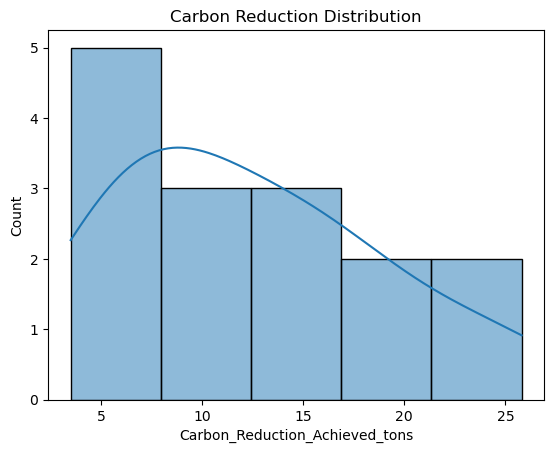

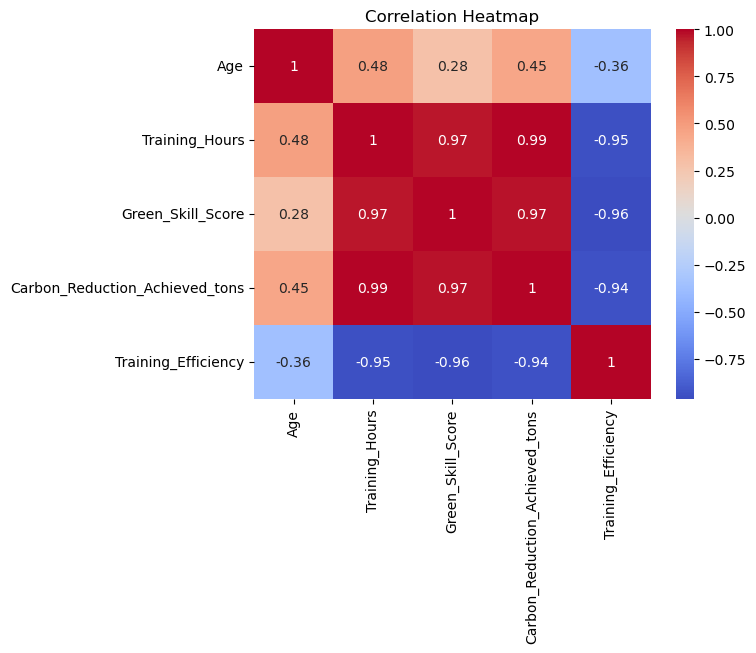

MAE: 0.648579167020055
MSE: 0.45405575633170575
RMSE: 0.6738365946813113
R2 Score: 0.9773500620386578
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



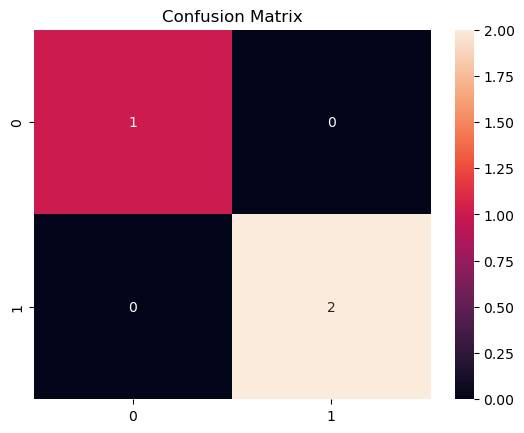

  City_ID  Population_Lakhs Industrial_Activity  Green_Coverage_Percentage  \
0    C001                12                High                         25   
1    C002                 8              Medium                         45   
2    C003                15                High                         20   
3    C004                 6                 Low                         65   
4    C005                10              Medium                         50   

   Energy_Consumption_MWh  Renewable_Energy_Usage_Percentage  \
0                     850                                 35   
1                     520                                 60   
2                     950                                 30   
3                     300                                 80   
4                     600                                 65   

  Eco_Friendly_Status  
0                  No  
1                 Yes  
2                  No  
3                 Yes  
4                 Yes  
<c

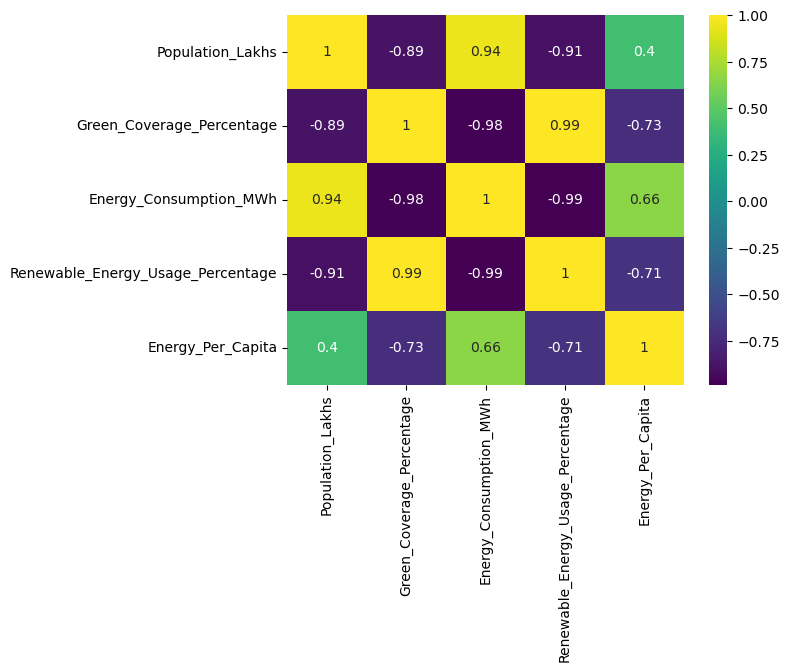

RMSE: 2.229724561014462
R2: 0.99037740977163
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
    r2_score, accuracy_score, classification_report,confusion_matrix)
import joblib
f1 = pd.read_csv("training.csv")
f2 = pd.read_csv("energy.csv")
print(f1.head())
print(f1.info())
print(f1.describe())

"""
Dataset 1 represents employee green skill development.

Observations:

1. Training hours represent employee sustainability learning.
2. Green Skill Score indicates environmental knowledge.
3. Higher training hours generally increase green skill score.
4. Employees with higher green skill scores achieve higher carbon reduction.
5. Energy saving practices strongly influence carbon reduction.
6. Sustainability certification depends mainly on skill score,
   training hours and environmental practices.

Feature Relationship:

Training_Hours ---> Green_Skill_Score

Green_Skill_Score ---> Carbon_Reduction_Achieved_tons

Energy_Saving_Practice ---> Carbon_Reduction_Achieved_tons

Higher Carbon Reduction ---> Higher probability of certification
"""
print(f1.isnull().sum())
f1.fillna(
    f1.mode().iloc[0],
    inplace=True)

f1["Training_Efficiency"] = (
    f1["Green_Skill_Score"] /
    f1["Training_Hours"]
)
sns.histplot(
    f1["Carbon_Reduction_Achieved_tons"],
    kde=True)
plt.title("Carbon Reduction Distribution")
plt.show()
sns.heatmap(
    f1.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()
X_reg = f1[
["Age","Training_Hours","Green_Skill_Score","Training_Efficiency"]
]
y_reg = f1["Carbon_Reduction_Achieved_tons"]
scaler = StandardScaler()

X_reg_scaled = scaler.fit_transform(X_reg)
X_train, X_test, y_train, y_test = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)


prediction = linear_model.predict(X_test)
print("MAE:",mean_absolute_error(y_test,prediction))
print("MSE:",mean_squared_error(y_test,prediction))
print("RMSE:",np.sqrt(mean_squared_error(y_test,prediction)))
print("R2 Score:",r2_score(y_test,prediction))
"""
Regression Insights:

MAE:
Average difference between actual and predicted carbon reduction.

MSE:
Penalizes larger prediction errors.

RMSE:
Shows error in same unit as carbon reduction.

R2 Score:
Shows how much variation in carbon reduction
is explained by the model.

Higher R2 means better prediction.
"""
joblib.dump(linear_model,"LinearRegression.pkl")
X_cls = f1[
["Age","Training_Hours","Green_Skill_Score","Training_Efficiency","Energy_Saving_Practice"]
]
y_cls = f1["Sustainability_Certified"]
X_cls = pd.get_dummies(
X_cls,
columns=["Energy_Saving_Practice"],
drop_first=True
)
encoder = LabelEncoder()
y_cls = encoder.fit_transform(y_cls)
X_cls_scaled = scaler.fit_transform(X_cls)
X_train, X_test, y_train, y_test = train_test_split(
X_cls_scaled,
y_cls,
test_size=0.2,
random_state=42
)
log_model = LogisticRegression()
log_model.fit(
X_train,
y_train
)


cls_prediction = log_model.predict(
X_test
)

print("Accuracy:",accuracy_score(y_test,cls_prediction)
)


print(
classification_report(
y_test,
cls_prediction
)
)


sns.heatmap(
confusion_matrix(
y_test,
cls_prediction
),
annot=True
)

plt.title(
"Confusion Matrix"
)

plt.show()



"""
Classification Insights:

Accuracy tells percentage of correct certification predictions.

Precision:
Out of predicted certified employees,
how many were actually certified.

Recall:
How many actual certified employees
were correctly identified.

F1-score:
Balance between precision and recall.
"""


# Save Logistic Regression

joblib.dump(
log_model,
"LogisticRegression.pkl"
)



# ==========================================================
# DATASET 2 : SUSTAINABLE CITY ENERGY ANALYSIS
# ==========================================================


print(f2.head())

print(f2.info())

print(f2.describe())


"""
Dataset Understanding:

This dataset contains sustainability information
of different cities.

Important relationships:

Green coverage increases renewable energy usage.

Industrial activity increases energy consumption.

Higher renewable energy usage indicates
better eco-friendly status.

Population affects energy demand.
"""
print(
f2.isnull().sum()
)


f2.fillna(
f2.mode().iloc[0],
inplace=True
)
f2[
"Energy_Per_Capita"
] = (
f2["Energy_Consumption_MWh"] /
f2["Population_Lakhs"]
)
sns.heatmap(
f2.corr(numeric_only=True),
annot=True,
cmap="viridis"
)

plt.show()
X = f2[
[
"Population_Lakhs",
"Green_Coverage_Percentage",
"Energy_Consumption_MWh",
"Energy_Per_Capita"
]
]


y = f2[
"Renewable_Energy_Usage_Percentage"
]


X = StandardScaler().fit_transform(X)



X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)


model = LinearRegression()

model.fit(
X_train,
y_train
)


pred = model.predict(
X_test
)


print(
"RMSE:",
np.sqrt(
mean_squared_error(
y_test,
pred
))
)


print(
"R2:",
r2_score(
y_test,
pred
)
)



# ============================
# Classification
# ============================


X = f2[
[
"Population_Lakhs",
"Green_Coverage_Percentage",
"Energy_Consumption_MWh",
"Industrial_Activity"
]
]


y = f2[
"Eco_Friendly_Status"
]


X = pd.get_dummies(
X,
columns=[
"Industrial_Activity"
],
drop_first=True
)


y = LabelEncoder().fit_transform(y)



X = StandardScaler().fit_transform(X)



X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)



classifier = LogisticRegression()

classifier.fit(
X_train,
y_train
)


prediction = classifier.predict(
X_test
)



print(
accuracy_score(
y_test,
prediction
)
)


print(
classification_report(
y_test,
prediction
)
)

### Model Evaluation Insights

The Linear Regression model was used to predict sustainability-related values like carbon reduction and renewable energy usage. Lower MAE, MSE, and RMSE values indicate that the model's predictions are closer to the actual values, while a higher R² score shows better prediction performance.

The Logistic Regression model was used for classification tasks like predicting sustainability certification and eco-friendly status. Accuracy, precision, recall, and F1-score help measure how correctly the model classifies different categories.

Overall, the models show that green skills, training hours, renewable energy usage, and green coverage have a positive impact on sustainability outcomes. Some errors occur because sustainability depends on many external factors that are not included in the dataset.